# Driver Face Detection & Visualization (DMD + OpenLABEL)
This notebook walks you through:
1. Installing dependencies  
2. Loading an MP4 video stream  
3. Parsing **OpenLABEL** JSON from the Driver Monitoring Dataset (DMD)  
4. Detecting faces (OpenCV Haar cascade)  
5. Visualizing detections **and** ground‑truth labels side by side on the frames  
6. Exporting an annotated MP4  
7. (Optional) Cropping/saving driver face chips

> **Tip:** If you also want landmarks/mesh, you can switch the detector to **MediaPipe Face Detection / Face Mesh** in the detector cell.


## Imports & Paths

In [ ]:
import cv2, json, re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
#from tqdm import tqdm

%matplotlib inline


# Visualization settings
DRAW_LABELS = True       # draw ground‑truth boxes from OpenLABEL
DRAW_DETECTIONS = True   # draw OpenCV detections
SAVE_ANNOTATED_VIDEO = True
SAVE_FACE_CROPS = False  # set True to export detected/labelled face crops as images

# Paths —> EDIT THESE to your files
PATH_MP4 = Path("/Users/mehaksaleem/Desktop/DOFG Project/More_Data/dmd_5/frames.mp4")        
PATH_OPENLABEL_JSON = Path("/Users/mehaksaleem/Desktop/DOFG Project/More_Data/dmd_5/labels.json")
OUT_VIDEO = PATH_MP4.with_name(PATH_MP4.stem + '_annotated.mp4')
OUT_CROPS_DIR = PATH_MP4.with_name(PATH_MP4.stem + '_face_crops')


def _must_exist(p, label):
    if p is None:
        raise FileNotFoundError(f"{label}: path is None (auto-search probably failed). Set it explicitly.")
    if not p.exists():
        raise FileNotFoundError(f"{label} not found: {p}\n"
                                "Tips: 1) Use raw strings r'...'; 2) Include the file *name*; 3) Use forward slashes on Windows.")
    return p

PATH_MP4 = _must_exist(PATH_MP4, "Video")
PATH_OPENLABEL_JSON = _must_exist(PATH_OPENLABEL_JSON, "OpenLABEL JSON")

print("Using:")
print("  Video :", PATH_MP4)
print("  Labels:", PATH_OPENLABEL_JSON)

# Frame offset if labels look shifted vs frames (try 0, +1, or -1)
LABEL_FRAME_OFFSET = 0

FileNotFoundError: Video not found: /Users/mehaksaleem/Desktop/DOFG Project/More_Data/dmd_5/frames.mp4
Tips: 1) Use raw strings r'...'; 2) Include the file *name*; 3) Use forward slashes on Windows.

: 

## Video info (FPS, width, height, frames)

In [56]:
cap = cv2.VideoCapture(str(PATH_MP4))
assert cap.isOpened(), "Failed to open video."

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video: {W}x{H} @ {fps:.2f} fps, frames={N}")


Video: 1280x720 @ 29.76 fps, frames=5294


In [57]:
import json, re
from pathlib import Path
import cv2

def _find_fps_in_streams(openlabel_dict):
    streams = openlabel_dict.get("streams", {})
    # Try common locations/keys
    candidates = []
    for sid, srec in (streams or {}).items():
        # Flatten dict to strings to heuristically find fps-like values
        def walk(d):
            for k,v in (d or {}).items():
                if isinstance(v, dict):
                    yield from walk(v)
                else:
                    yield (k, v)
        for k,v in walk(srec):
            # numeric
            if isinstance(v, (int, float)) and 0 < v < 200:
                if any(tok in str(k).lower() for tok in ["fps","frame_rate","framerate","sample_rate"]):
                    candidates.append(float(v))
            # strings like "30", "30.0", "30fps"
            if isinstance(v, str):
                m = re.search(r"(\d+(\.\d+)?)\s*fps", v.lower())
                if m:
                    candidates.append(float(m.group(1)))
                else:
                    try:
                        val = float(v)
                        if 0 < val < 200 and any(tok in str(k).lower() for tok in ["fps","frame_rate","framerate","sample_rate"]):
                            candidates.append(val)
                    except:
                        pass
    return candidates[0] if candidates else None

# Load JSON
with open(PATH_OPENLABEL_JSON, "r", encoding="utf-8") as f:
    _data = json.load(f)
_ol = _data.get("openlabel", _data)

json_fps = _find_fps_in_streams(_ol)

# MP4 FPS
_cap = cv2.VideoCapture(str(PATH_MP4))
assert _cap.isOpened(), f"Failed to open video: {PATH_MP4}"
video_fps = _cap.get(cv2.CAP_PROP_FPS) or 30.0
_cap.release()

print(f"JSON streams FPS: {json_fps}")
print(f"MP4 reported FPS: {video_fps:.3f}")
print("Use the MP4 FPS for playback/export. JSON FPS is only a sanity check.")


JSON streams FPS: None
MP4 reported FPS: 29.760
Use the MP4 FPS for playback/export. JSON FPS is only a sanity check.


##  Taxonomy-based mapper

In [58]:
# Eyes are occluded ONLY when "closed" (change to {"closed","closing"} if you prefer)
EYES_OCCLUDED_WHEN = {"closed"}

OCCLUSION_SUBTYPES = {
    "face occlusion": "face",
    "body occlusion": "body",
    "hands occlusion": "hands"
}
EYES_STATES = {"opened","closed","opening","closing","undefined"}
YAWN_SUBTYPES = {
    "yawning with hand": "with_hand",
    "yawning without hand": "no_hand"
}
BLINK_TYPES = {"blinking"}

def _norm(s): return re.sub(r"\s+", " ", s.strip().lower())

def _map_action_type_to_struct(action_type_str):
    out = {}
    if not action_type_str: return out
    t = _norm(action_type_str)

    if "/" in t:
        head, tail = t.split("/", 1)
        head, tail = _norm(head), _norm(tail)
    else:
        head, tail = t, ""

    # Occlusion
    if head == "occlusion":
        out["occlusion"] = OCCLUSION_SUBTYPES.get(tail) or next((v for k,v in OCCLUSION_SUBTYPES.items() if k in t), None)

    # Eyes state
    elif head == "eyes_state":
        if tail in EYES_STATES:
            out["eyes_state"] = tail
            out["eyes_occluded"] = tail in EYES_OCCLUDED_WHEN

    # Blinks
    elif head == "blinks" or "blink" in head or "blink" in tail:
        out["blink"] = True

    # Yawning
    elif head == "yawning" or "yawn" in head:
        out["yawn"] = True
        if tail in YAWN_SUBTYPES:
            out["yawn_subtype"] = YAWN_SUBTYPES[tail]
        else:
            for k,v in YAWN_SUBTYPES.items():
                if k in t: out["yawn_subtype"] = v

    if not out:
        out[f"unmapped::{t}"] = True
    return out


## Build per-frame flags

In [59]:
def build_action_flags_by_frame_strict(path_json):
    with open(path_json, "r", encoding="utf-8") as f:
        data = json.load(f)
    ol = data.get("openlabel", data)
    frames = ol.get("frames") or {}
    actions_top = ol.get("actions", {}) or {}

    flags_by_frame = defaultdict(dict)

    # Frame-local (rare)
    for fkey, frec in frames.items():
        try: fid = int(fkey)
        except: 
            try: fid = int(round(float(fkey)))
            except: continue
        for _, arec in (frec.get("actions") or {}).items():
            atype = arec.get("type") or arec.get("name") or ""
            m = _map_action_type_to_struct(atype)
            flags_by_frame[fid].update(m)

    # Top-level intervals
    for aid, arec in actions_top.items():
        atype = arec.get("type") or arec.get("name") or ""
        m = _map_action_type_to_struct(atype)
        if not m: continue
        for iv in (arec.get("frame_intervals") or []):
            fs = int(iv.get("frame_start", 0))
            fe = int(iv.get("frame_end", fs))
            for fid in range(fs, fe + 1):
                flags_by_frame[fid].update(m)

    return dict(flags_by_frame)

flags_by_frame = build_action_flags_by_frame_strict(PATH_OPENLABEL_JSON)
print("Frames with flags:", len(flags_by_frame))
for k in sorted(flags_by_frame.keys())[:10]:
    print(k, flags_by_frame[k])


Frames with flags: 5294
0 {'unmapped::eyes_state/open': True}
1 {'unmapped::eyes_state/open': True}
2 {'unmapped::eyes_state/open': True}
3 {'unmapped::eyes_state/open': True}
4 {'unmapped::eyes_state/open': True}
5 {'unmapped::eyes_state/open': True}
6 {'unmapped::eyes_state/open': True}
7 {'unmapped::eyes_state/open': True}
8 {'unmapped::eyes_state/open': True}
9 {'unmapped::eyes_state/open': True}


## Face detector

In [60]:
cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(cascade_path)

def detect_faces_bgr(frame_bgr):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    return face_cascade.detectMultiScale(gray, 1.1, 4, minSize=(30, 30))

def draw_box(img, xywh, color=(0,255,0), label=None):
    x,y,w,h = map(int, xywh)
    cv2.rectangle(img, (x,y), (x+w, y+h), color, 2)
    if label:
        cv2.putText(img, label, (x, max(0,y-6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)


## Formatter for overlay text

In [61]:
def _fmt_flags_for_overlay_strict(flags: dict):
    parts = []

    # Special phrase
    if flags.get("yawn") and flags.get("eyes_occluded"):
        parts.append("yawning & eyes occluded")

    if "occlusion" in flags and flags["occlusion"]:
        parts.append(f"occlusion: {flags['occlusion']}")

    if "eyes_state" in flags:
        es = flags["eyes_state"]
        if flags.get("eyes_occluded"):
            parts.append(f"eyes: {es} (occluded)")
        else:
            parts.append(f"eyes: {es}")

    if flags.get("blink"):
        parts.append("blink")

    if flags.get("yawn"):
        ys = flags.get("yawn_subtype")
        if ys == "with_hand":
            parts.append("yawning (with hand)")
        elif ys == "no_hand":
            parts.append("yawning (no hand)")
        else:
            parts.append("yawning")

    for k,v in flags.items():
        if k.startswith("unmapped::") and v:
            parts.append(k)

    return " | ".join(parts)


## Preview some frames

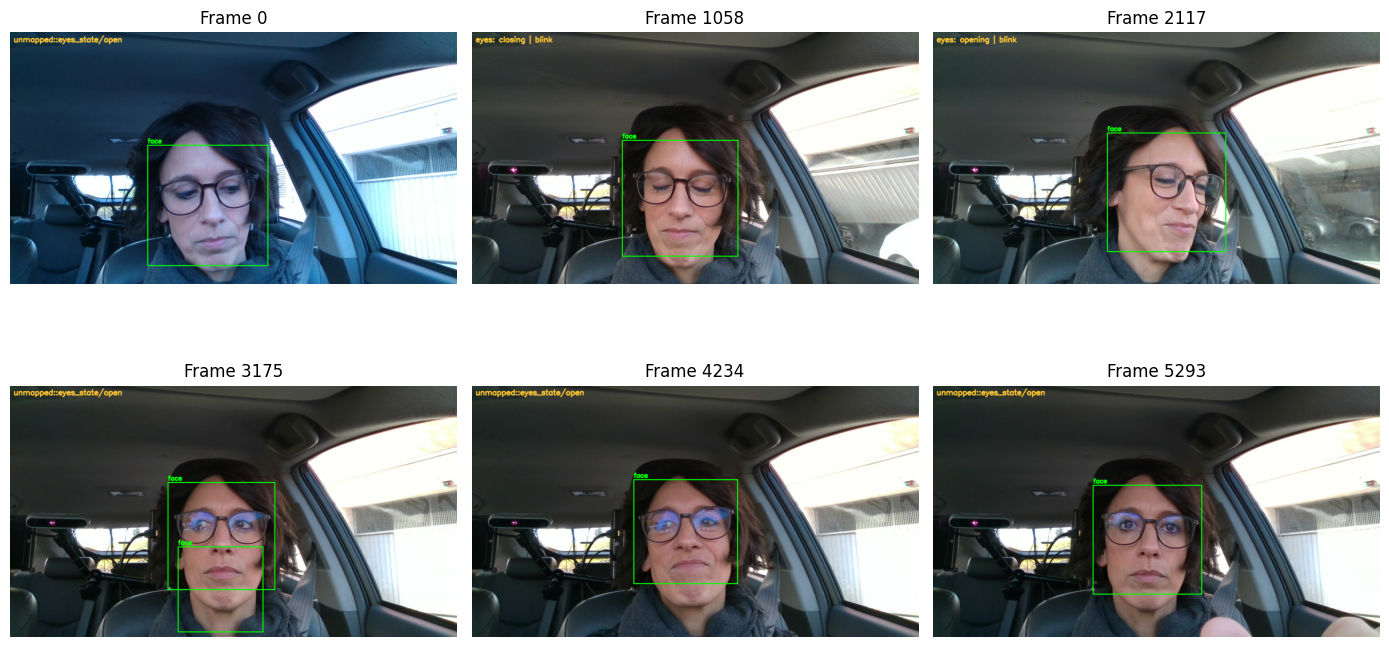

In [62]:
def get_flags_for_frame(fid): 
    return flags_by_frame.get(fid + LABEL_FRAME_OFFSET, {})

sample_ids = np.linspace(0, N-1, num=min(6, N)).astype(int)

plt.figure(figsize=(14, 8))
for i, fid in enumerate(sample_ids, 1):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    ok, frame = cap.read()
    if not ok: break
    vis = frame.copy()

    for (x,y,w,h) in detect_faces_bgr(vis):
        draw_box(vis, (x,y,w,h), (0,255,0), "face")

    text = _fmt_flags_for_overlay_strict(get_flags_for_frame(fid))
    if text:
        y0 = 28
        for line in [text[i:i+60] for i in range(0,len(text),60)]:
            cv2.putText(vis, line, (10,y0), cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                        (50,200,255), 2, cv2.LINE_AA)
            y0 += 24

    plt.subplot(2,3,i)
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {fid}")
    plt.axis("off")
plt.tight_layout()


## Optional: switch to MediaPipe Face Detection
If Haar cascade misses faces (profile views / occlusions), try MediaPipe. Uncomment below after installing `mediapipe`.


In [50]:
# from mediapipe.tasks import python as mp_python
# from mediapipe.tasks.python import vision as mp_vision
# from mediapipe import Image as MPImage
# import mediapipe as mp

# # This setup uses the default short‑range model.
# base_options = mp.tasks.BaseOptions(model_asset_path=None)  # will auto‑download
# options = mp_vision.FaceDetectorOptions(base_options=base_options,
#                                         running_mode=mp_vision.RunningMode.IMAGE)
# detector = mp_vision.FaceDetector.create_from_options(options)

# def detect_faces_mediapipe_bgr(frame_bgr):
#     mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
#     result = detector.detect(mp_img)
#     boxes = []
#     if result and result.detections:
#         for d in result.detections:
#             bb = d.bounding_box
#             boxes.append([bb.origin_x, bb.origin_y, bb.width, bb.height])
#     return boxes

# # Then replace detect_faces_bgr with detect_faces_mediapipe_bgr in the loop above.


## (Optional) IoU between detections and labels
This cell gives a rough alignment score to check if detections line up with the labelled driver bbox.


In [ ]:
# def iou_xywh(a, b):
#     ax, ay, aw, ah = a
#     bx, by, bw, bh = b
#     ax2, ay2 = ax+aw, ay+ah
#     bx2, by2 = bx+bw, by+bh
#     inter_x1, inter_y1 = max(ax, bx), max(ay, by)
#     inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
#     iw, ih = max(0, inter_x2-inter_x1), max(0, inter_y2-inter_y1)
#     inter = iw*ih
#     union = aw*ah + bw*bh - inter + 1e-9
#     return inter/union

# # sample ~200 frames uniformly
# cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
# num_samples = min(200, nframes)
# step = max(1, nframes // num_samples)

# ious = []
# idx = 0
# for frame_idx in range(0, nframes, step):
#     ok, frame = grab_frame(cap, frame_idx)
#     if not ok: break
#     dets = detect_faces_bgr(frame)
#     lbls = [o['bbox'] for o in get_labels_for_frame(frame_idx)]
#     # Just take best pairing (greedy)
#     for d in dets:
#         if lbls:
#             best = max(iou_xywh(d, l) for l in lbls)
#             ious.append(best)
# if ious:
#     print(f'IoU mean={np.mean(ious):.3f}, median={np.median(ious):.3f}, n={len(ious)}')
# else:
#     print('No overlaps to compute IoU.')

: 

## Labelling data

In [63]:
# --- Parse DMD OpenLABEL into frame-wise arrays for eyes/yawns (robust to "eye_state"/"eyes_state" + open/close variants) ---

import json
import numpy as np
import cv2
from pathlib import Path  # ensure Path is available

# Toggles
PREFER_VIDEO_FRAMECOUNT = True   # if True and PATH_MP4 exists, use video framecount (N) over JSON total_frames

# Canonical eye states we want to fill
VALID_EYE_STATES = {"opened","opening","closed","closing","undefined"}

def _norm(s):
    return (" ".join(s.strip().lower().split())) if isinstance(s, str) else s

def _get_total_frames_from_json(openlabel_dict):
    """Try to read total_frames for face camera; fallback to max interval end across actions."""
    streams = openlabel_dict.get("streams") or {}
    # Heuristic: any stream may expose total_frames
    for _, srec in streams.items():
        for k in ("total_frames","frames","num_frames"):
            v = srec.get(k)
            if isinstance(v, int) and v > 0:
                return int(v)
    # Fallback: infer from actions
    actions = openlabel_dict.get("actions") or {}
    max_end = 0
    for _, arec in actions.items():
        for iv in (arec.get("frame_intervals") or []):
            fe = int(iv.get("frame_end", 0))
            if fe > max_end:
                max_end = fe
    return max_end + 1 if max_end > 0 else None

def _get_video_framecount_and_fps(mp4_path: Path):
    if mp4_path is None or not mp4_path.exists():
        return None, None
    cap = cv2.VideoCapture(str(mp4_path))
    if not cap.isOpened():
        return None, None
    fps_v = cap.get(cv2.CAP_PROP_FPS) or 30.0
    n_v = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    cap.release()
    return (n_v if n_v > 0 else None), fps_v

def _extract_glasses(openlabel_dict):
    """Return True if driver object has glasses=True anywhere."""
    objs = openlabel_dict.get("objects") or {}
    for _, orec in objs.items():
        for b in (orec.get("object_data", {}).get("boolean") or []):
            if _norm(b.get("name")) == "glasses":
                return bool(b.get("val"))
    return False

# Tail synonyms → canonical eye state
EYE_TAIL_ALIASES = {
    "open": "opened",
    "opened": "opened",
    "opening": "opening",
    "close": "closed",
    "closed": "closed",
    "closing": "closing",
    "undef": "undefined",
    "undefined": "undefined",
}

def _is_eyes_state_head(head_norm: str):
    """Accept both eyes_state and eye_state (and minor formatting variants)."""
    hn = head_norm.replace("-", "_").replace(" ", "_")
    return hn in {"eyes_state", "eye_state", "eyesstate", "eyestate"}

# Load JSON
with open(PATH_OPENLABEL_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)
ol = data.get("openlabel", data)

# Determine N (frame count) and fps
N_json = _get_total_frames_from_json(ol)
N_vid, fps_vid = _get_video_framecount_and_fps(PATH_MP4) if 'PATH_MP4' in globals() else (None, None)

if PREFER_VIDEO_FRAMECOUNT and N_vid:
    N = N_vid
    fps = fps_vid or 30.0
else:
    N = N_json if N_json else (N_vid or 0)
    fps = fps_vid or 30.0

assert N > 0, "Could not determine total frames (N) from JSON streams or video."

# Prepare arrays
is_opened   = np.zeros(N, dtype=bool)
is_opening  = np.zeros(N, dtype=bool)
is_closed   = np.zeros(N, dtype=bool)
is_closing  = np.zeros(N, dtype=bool)
is_undef    = np.zeros(N, dtype=bool)

is_yawn_with_hand    = np.zeros(N, dtype=bool)
is_yawn_without_hand = np.zeros(N, dtype=bool)

# Parse actions (top-level intervals)
actions = ol.get("actions") or {}
for _, arec in actions.items():
    atype = _norm(arec.get("type") or arec.get("name") or "")
    if not atype:
        continue
    head, tail = (atype.split("/", 1) + [""])[:2]
    head, tail = _norm(head), _norm(tail)
    intervals = arec.get("frame_intervals") or []

    # ---- Eyes state (robust head + tail synonyms) ----
    if _is_eyes_state_head(head):
        tail_canon = EYE_TAIL_ALIASES.get(tail)
        if tail_canon in VALID_EYE_STATES:
            tgt = {
                "opened":    is_opened,
                "opening":   is_opening,
                "closed":    is_closed,
                "closing":   is_closing,
                "undefined": is_undef
            }[tail_canon]
            for iv in intervals:
                fs = int(iv.get("frame_start", 0)); fe = int(iv.get("frame_end", fs))
                tgt[fs:fe+1] = True

    # ---- Yawning (keep original handling; robust to case) ----
    elif head == "yawning" or "yawn" in head:
        # normalize tail to two buckets
        t = tail.replace("_", " ")
        if "with hand" in t:
            tgt = is_yawn_with_hand
        elif "without hand" in t:
            tgt = is_yawn_without_hand
        else:
            # try exact canonical forms
            if t == "yawning with hand":
                tgt = is_yawn_with_hand
            elif t == "yawning without hand":
                tgt = is_yawn_without_hand
            else:
                continue
        for iv in intervals:
            fs = int(iv.get("frame_start", 0)); fe = int(iv.get("frame_end", fs))
            tgt[fs:fe+1] = True

# Subject attribute: glasses
glasses = _extract_glasses(ol)

# Helpful combined views
is_eyeclosed_any = np.logical_or(is_closed, is_closing)
is_eyeopen_any   = np.logical_or(is_opened, is_opening)

# Optional: detect contradictions (frames marked both open-any and closed-any)
contradictions = int(np.logical_and(is_eyeopen_any, is_eyeclosed_any).sum())

print(f"Arrays built for N={N} frames | glasses={glasses} | fps≈{fps:.2f}")
print("Counts:",
      "opened",   int(is_opened.sum()),
      "opening",  int(is_opening.sum()),
      "closed",   int(is_closed.sum()),
      "closing",  int(is_closing.sum()),
      "closed_or_closing", int(is_eyeclosed_any.sum()),
      "opened_or_opening", int(is_eyeopen_any.sum()),
      "undef",    int(is_undef.sum()),
      "| yawn_with_hand", int(is_yawn_with_hand.sum()),
      "yawn_without_hand", int(is_yawn_without_hand.sum()))
print("Eye-state contradictions (open-any ∩ closed-any):", contradictions)


Arrays built for N=5294 frames | glasses=True | fps≈29.76
Counts: opened 3560 opening 776 closed 397 closing 559 closed_or_closing 956 opened_or_opening 4336 undef 2 | yawn_with_hand 362 yawn_without_hand 339
Eye-state contradictions (open-any ∩ closed-any): 0


In [64]:
# --- Collapse to {Neutral, EyeClosed, Yawn} + occlusion flags and export ---

import csv
from collections import Counter

# Policy toggles
OCCLUDE_ON_GLASSES = True         # treat glasses as a soft prior for eye occlusion
UNDEFINED_AS_NEUTRAL = True       # if False, undefined frames will be dropped

def derive_class(i):
    # 1) Yawn wins
    if is_yawn_with_hand[i] or is_yawn_without_hand[i]:
        return "Yawn"

    # 2) EyeClosed = closed or closing
    if is_closed[i] or is_closing[i]:
        return "EyeClosed"

    # 3) Neutral = opened or opening
    if is_opened[i] or is_opening[i]:
        return "Neutral"

    # 4) undefined
    if is_undef[i]:
        return "Neutral" if UNDEFINED_AS_NEUTRAL else None

    # Fallback (shouldn’t happen): treat as Neutral or drop
    return "Neutral" if UNDEFINED_AS_NEUTRAL else None

def derive_occlusion_flags(i):
    # Mouth occlusion prior: yawn with hand → likely hand near/covering mouth
    mouth_occluded_prior = bool(is_yawn_with_hand[i])
    # Eyes occlusion prior: glasses (static)
    eyes_occluded_prior = bool(glasses) if OCCLUDE_ON_GLASSES else False
    return {
        "eyes_occluded_prior": eyes_occluded_prior,
        "mouth_occluded_prior": mouth_occluded_prior,
    }

def build_records():
    records = []
    for i in range(N):
        cls = derive_class(i)
        if cls is None:          # drop undefined if configured
            continue
        occ = derive_occlusion_flags(i)

        rec = {
            "frame": i,
            "timestamp_s": i/float(fps) if fps else None,
            "class": cls,  # Neutral | EyeClosed | Yawn
            "variant": f"{cls}{'_Occluded' if (occ['eyes_occluded_prior'] or occ['mouth_occluded_prior']) else ''}",
            # extras for analysis/debug
            "eyes_state": ("closed" if is_closed[i] else
                           "closing" if is_closing[i] else
                           "opening" if is_opening[i] else
                           "opened" if is_opened[i] else
                           "undefined" if is_undef[i] else None),
            "yawn_with_hand": bool(is_yawn_with_hand[i]),
            "yawn_without_hand": bool(is_yawn_without_hand[i]),
            "eyes_occluded_prior": occ["eyes_occluded_prior"],
            "mouth_occluded_prior": occ["mouth_occluded_prior"],
            "glasses": bool(glasses),
        }
        records.append(rec)
    return records

records = build_records()

print("Class distribution:", Counter(r["class"] for r in records))
print("Yawn_with_hand frames:", sum(r["yawn_with_hand"] for r in records))
print("Yawn_without_hand frames:", sum(r["yawn_without_hand"] for r in records))

# Export CSV
OUT_CSV = PATH_OPENLABEL_JSON.with_name(PATH_OPENLABEL_JSON.stem + "_impl_labels.csv")
cols = ["frame","timestamp_s","class","variant","eyes_state",
        "yawn_with_hand","yawn_without_hand",
        "eyes_occluded_prior","mouth_occluded_prior","glasses"]

with open(OUT_CSV, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=cols)
    w.writeheader()
    w.writerows(records)

print("Wrote:", OUT_CSV)


Class distribution: Counter({'Neutral': 3827, 'EyeClosed': 766, 'Yawn': 701})
Yawn_with_hand frames: 362
Yawn_without_hand frames: 339
Wrote: /Users/mehaksaleem/Desktop/DOFG Project/More_Data/dmd_5/labels_impl_labels.csv


In [12]:
def map_dmd_to_refined_dms_states(flags: dict):
    """
    Map DMD labels to your refined DMS states with occlusion handling
    """
    # Extract key information
    eye_state = flags.get('eyes_state', 'opened')
    is_yawning = flags.get('yawn', False)
    yawn_subtype = flags.get('yawn_subtype', None)
    has_glasses = flags.get('glasses', False)  # Look for glasses in JSON
    occlusion_type = flags.get('occlusion', None)
    
    # Determine primary state
    eyes_closed = eye_state in ['closed', 'closing'] or flags.get('blink', False)
    
    # State determination logic
    if is_yawning:
        if yawn_subtype == "with_hand" or occlusion_type == "hands":
            return {
                'state': 'Yawn_with_occlusion',
                'eyes_closed': eyes_closed,
                'mouth_open': True,
                'occlusion_present': True,
                'occlusion_source': 'hands'
            }
        else:
            return {
                'state': 'Yawn',
                'eyes_closed': eyes_closed,
                'mouth_open': True,
                'occlusion_present': False,
                'occlusion_source': None
            }
    
    # Non-yawning states (mouth closed)
    elif eyes_closed:
        if has_glasses:
            return {
                'state': 'EyeClosed_with_occlusion',
                'eyes_closed': True,
                'mouth_open': False,
                'occlusion_present': True,
                'occlusion_source': 'glasses'
            }
        else:
            return {
                'state': 'EyeClosed',
                'eyes_closed': True,
                'mouth_open': False,
                'occlusion_present': False,
                'occlusion_source': None
            }
    
    else:  # Eyes open, mouth closed
        if has_glasses:
            return {
                'state': 'Neutral_with_occlusion',
                'eyes_closed': False,
                'mouth_open': False,
                'occlusion_present': True,
                'occlusion_source': 'glasses'
            }
        else:
            return {
                'state': 'Neutral',
                'eyes_closed': False,
                'mouth_open': False,
                'occlusion_present': False,
                'occlusion_source': None
            }

In [13]:
def _map_action_type_to_struct_enhanced(action_type_str):
    """Enhanced mapper that includes glasses detection"""
    out = {}
    if not action_type_str: 
        return out
    
    t = _norm(action_type_str)
    
    if "/" in t:
        head, tail = t.split("/", 1)
        head, tail = _norm(head), _norm(tail)
    else:
        head, tail = t, ""
    
    # Glasses detection
    if "glasses" in t or "eyewear" in t:
        out["glasses"] = True
    
    # Occlusion detection
    if head == "occlusion":
        out["occlusion"] = OCCLUSION_SUBTYPES.get(tail) or next(
            (v for k,v in OCCLUSION_SUBTYPES.items() if k in t), None)
    
    # Eyes state
    elif head == "eyes_state":
        if tail in EYES_STATES:
            out["eyes_state"] = tail
            out["eyes_occluded"] = tail in EYES_OCCLUDED_WHEN
    
    # Blinks
    elif head == "blinks" or "blink" in head or "blink" in tail:
        out["blink"] = True
    
    # Yawning
    elif head == "yawning" or "yawn" in head:
        out["yawn"] = True
        if tail in YAWN_SUBTYPES:
            out["yawn_subtype"] = YAWN_SUBTYPES[tail]
        else:
            for k,v in YAWN_SUBTYPES.items():
                if k in t: 
                    out["yawn_subtype"] = v
    
    return out

In [14]:
def build_filtered_dms_labels_by_frame(path_json, target_states=None):
    """
    Build DMS labels with filtering for unwanted states
    """
    if target_states is None:
        target_states = {
            'Neutral', 'EyeClosed', 'Yawn', 
            'Yawn_with_occlusion', 'EyeClosed_with_occlusion', 
            'Neutral_with_occlusion'
        }
    
    with open(path_json, "r", encoding="utf-8") as f:
        data = json.load(f)
    ol = data.get("openlabel", data)
    frames = ol.get("frames") or {}
    actions_top = ol.get("actions", {}) or {}
    
    filtered_labels_by_frame = {}
    ignored_frames = []
    
    # Build complete flags first
    all_flags_by_frame = defaultdict(dict)
    
    # Frame-local actions
    for fkey, frec in frames.items():
        try: 
            fid = int(fkey)
        except: 
            continue
        
        for _, arec in (frec.get("actions") or {}).items():
            atype = arec.get("type") or arec.get("name") or ""
            mapped = _map_action_type_to_struct_enhanced(atype)
            all_flags_by_frame[fid].update(mapped)
    
    # Top-level intervals
    for aid, arec in actions_top.items():
        atype = arec.get("type") or arec.get("name") or ""
        mapped = _map_action_type_to_struct_enhanced(atype)
        if not mapped: 
            continue
            
        for iv in (arec.get("frame_intervals") or []):
            fs = int(iv.get("frame_start", 0))
            fe = int(iv.get("frame_end", fs))
            for fid in range(fs, fe + 1):
                all_flags_by_frame[fid].update(mapped)
    
    # Filter and convert to DMS states
    for fid, flags in all_flags_by_frame.items():
        dms_state = map_dmd_to_refined_dms_states(flags)
        
        if dms_state['state'] in target_states:
            filtered_labels_by_frame[fid] = dms_state
        else:
            ignored_frames.append(fid)
    
    print(f"Kept {len(filtered_labels_by_frame)} frames")
    print(f"Ignored {len(ignored_frames)} frames")
    print(f"State distribution: {get_state_distribution(filtered_labels_by_frame)}")
    
    return filtered_labels_by_frame, ignored_frames

def get_state_distribution(labels_dict):
    """Get distribution of states in the dataset"""
    from collections import Counter
    states = [label['state'] for label in labels_dict.values()]
    return Counter(states)

In [15]:
def extract_relevant_segments(video_path, json_path, filtered_labels, 
                            min_segment_length=30, output_dir=None):
    """
    Extract video segments that contain your target states
    """
    if output_dir is None:
        output_dir = Path(video_path).parent / "filtered_segments"
    output_dir.mkdir(exist_ok=True)
    
    # Group consecutive frames
    frame_ids = sorted(filtered_labels.keys())
    segments = []
    current_segment = [frame_ids[0]]
    
    for i in range(1, len(frame_ids)):
        if frame_ids[i] - frame_ids[i-1] <= 5:  # Allow small gaps
            current_segment.append(frame_ids[i])
        else:
            if len(current_segment) >= min_segment_length:
                segments.append(current_segment)
            current_segment = [frame_ids[i]]
    
    # Add last segment
    if len(current_segment) >= min_segment_length:
        segments.append(current_segment)
    
    print(f"Found {len(segments)} relevant segments")
    
    # Extract segments
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    for i, segment_frames in enumerate(segments):
        start_frame = segment_frames[0]
        end_frame = segment_frames[-1]
        
        # Create segment info
        segment_info = {
            'segment_id': i,
            'start_frame': start_frame,
            'end_frame': end_frame,
            'duration_seconds': (end_frame - start_frame) / fps,
            'states': [filtered_labels[fid]['state'] for fid in segment_frames]
        }
        
        # Save segment info
        with open(output_dir / f"segment_{i}_info.json", 'w') as f:
            json.dump(segment_info, f, indent=2)
        
        print(f"Segment {i}: frames {start_frame}-{end_frame}, "
              f"duration: {segment_info['duration_seconds']:.1f}s")
    
    cap.release()
    return segments

In [16]:
class RefinedDMSProcessor:
    def __init__(self, video_path, json_path):
        self.video_path = Path(video_path)
        self.json_path = Path(json_path)
        
        # Build filtered labels
        self.dms_labels, self.ignored_frames = build_filtered_dms_labels_by_frame(
            json_path
        )
        
        # Initialize video capture
        self.cap = cv2.VideoCapture(str(video_path))
        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
        
    def get_training_samples(self):
        """
        Get all valid training samples for your DMS
        """
        samples = []
        
        for frame_id, label_info in tqdm(self.dms_labels.items(), 
                                       desc="Processing valid frames"):
            # Read frame
            self.cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
            ok, frame = self.cap.read()
            
            if not ok:
                continue
                
            sample = {
                'frame': frame,
                'frame_id': frame_id,
                'state': label_info['state'],
                'eyes_closed': label_info['eyes_closed'],
                'mouth_open': label_info['mouth_open'],
                'has_occlusion': label_info['occlusion_present'],
                'occlusion_source': label_info['occlusion_source'],
                'timestamp': frame_id / self.fps
            }
            
            samples.append(sample)
        
        return samples
    
    def save_processed_dataset(self, output_path):
        """Save processed dataset for training"""
        samples = self.get_training_samples()
        
        # Save as compressed numpy arrays
        output_path = Path(output_path)
        output_path.mkdir(exist_ok=True)
        
        frames = np.array([s['frame'] for s in samples])
        labels = [s['state'] for s in samples]
        metadata = [{k: v for k, v in s.items() if k != 'frame'} 
                   for s in samples]
        
        np.save(output_path / 'frames.npy', frames)
        
        with open(output_path / 'labels.json', 'w') as f:
            json.dump(labels, f)
            
        with open(output_path / 'metadata.json', 'w') as f:
            json.dump(metadata, f, indent=2)
        
        print(f"Saved {len(samples)} samples to {output_path}")
        return len(samples)

In [18]:
! uv pip install tqdm


Using Python 3.11.13 environment at: .venv-DMS
Audited 1 package in 1.76s


In [20]:
from tqdm import tqdm


In [21]:
# Process your data
processor = RefinedDMSProcessor(
    "/Users/mehaksaleem/Desktop/DOFG Project/More_Data/dmd_1/frames.mp4", 
    "/Users/mehaksaleem/Desktop/DOFG Project/More_Data/dmd_1/labels.json"
)

# Get state distribution
print("State distribution:")
for state, count in get_state_distribution(processor.dms_labels).items():
    print(f"  {state}: {count}")

# Extract relevant segments (optional - if you want shorter videos)
segments = extract_relevant_segments(
    processor.video_path, 
    processor.json_path, 
    processor.dms_labels,
    min_segment_length=30
)

# Get training samples
training_samples = processor.get_training_samples()

# Save processed dataset
processor.save_processed_dataset("output")

Kept 5377 frames
Ignored 0 frames
State distribution: Counter({'Neutral': 3098, 'EyeClosed': 1586, 'Yawn_with_occlusion': 361, 'Yawn': 332})
State distribution:
  Neutral: 3098
  EyeClosed: 1586
  Yawn: 332
  Yawn_with_occlusion: 361
Found 1 relevant segments
Segment 0: frames 0-5376, duration: 180.6s


Processing valid frames: 100%|██████████| 5377/5377 [03:38<00:00, 24.57it/s]


Saved 5377 samples to output


5377

### Notes
- If labels are time‑based rather than frame‑indexed, you may need to map timestamps → frames using FPS.  
- For yawning/eye‑occlusion status, add MediaPipe **Face Mesh** or a landmarks model and compute **Mouth Aspect Ratio (MAR)** and **Eye Aspect Ratio (EAR)** thresholds.  
- If your DMD labels include attributes per frame (e.g., `yawn=true`, `eyes_occluded=true`), draw them in the overlay text similarly to `label` above.
